# Análise Exploratória MDS - Escalonamento Multidimensional

O MDS tentará preservar as distâncias relativas entre os códigos. Devido à sua altíssima complexidade algorítmica ($O(N^2)$), é imperativo que você amostre os dados, caso contrário, o notebook não conseguirá finalizar a execução.

## 1. Importações básicas

In [11]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import MDS

sns.set_theme(style="whitegrid")
print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


## 2. Carregamento e Amostragem para o Hipercubo

O MDS calcula a matriz de distância cruzada de todos os registros. Inserir todos os milhares de pontos exigirá processamento exponencial e fará o kernel do seu Jupyter "morrer" por falta de RAM na sua máquina. A amostragem é técnica mandatória aqui

In [5]:
DATASET_PATH = '../formai_gold.parquet'
N_SAMPLES = 5_000  # Recomendado para processadores i5 e 8GB de RAM

In [6]:
df_gold = pd.read_parquet(DATASET_PATH)
# Selecionando uma amostra aleatória altamente representativa
df_sample = df_gold.sample(n=N_SAMPLES, random_state=42).copy()
print(f"Dataset carregado. Amostra isolada com {len(df_sample)} registros para calcular o MDS.")
df_sample.info()

Dataset carregado. Amostra isolada com 5000 registros para calcular o MDS.
<class 'pandas.DataFrame'>
Index: 5000 entries, 258505 to 495554
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   file_name              5000 non-null   str    
 1   category               5000 non-null   str    
 2   error_type             5000 non-null   str    
 3   num_lines              5000 non-null   float64
 4   cyclomatic_complexity  5000 non-null   float64
 5   token_count            5000 non-null   float64
 6   function_count         5000 non-null   float64
 7   avg_parameter_count    5000 non-null   float64
dtypes: float64(5), str(3)
memory usage: 629.1 KB


In [7]:
numeric_features = [
    'num_lines', 
    'cyclomatic_complexity', 
    'token_count', 
    'function_count', 
    'avg_parameter_count'
]

X_sample = df_sample[numeric_features]
y_sample = df_sample['category']

## 3. Aplicação do Algoritmo MDS

In [8]:
print("Treinando o MDS... O tempo de processamento durará entre 1 e 3 minutos na sua máquina.")

# O parâmetro normalized_stress resolve o aviso padrão da biblioteca no scikit-learn moderno
mds = MDS(n_components=2, random_state=42, n_init=4, max_iter=300, normalized_stress='auto')
X_mds = mds.fit_transform(X_sample)

df_mds = pd.DataFrame(data=X_mds, columns=['Dim_1', 'Dim_2'])
df_mds['category'] = y_sample.values

print(f"Transformação topológica concluída! Estresse final (Kruskal's Stress): {mds.stress_:.4f}")

Treinando o MDS... O tempo de processamento durará entre 1 e 3 minutos na sua máquina.


/home/deus/Documents/UEA/7_periodo/data_sci/pca_mds/ai-and-sec-issues_data-lake/.venv/lib/python3.14/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


Transformação topológica concluída! Estresse final (Kruskal's Stress): 2020653.8594


In [20]:
df_mds.category.value_counts()

category
VULNERABLE        4854
NON-VULNERABLE     146
Name: count, dtype: int64

## 4. Salvar e Visualizar os resultados da transformação MDS

In [14]:
MDS_RESULTS_PATH = 'mds_results.parquet'
MDS_IMAGE_PATH = 'mds_plot.png'

In [15]:
print("Salvando os resultados da amostra do MDS no disco...")
df_mds.to_parquet(MDS_RESULTS_PATH, engine='pyarrow', index=False)

print(f"Resultados do MDS salvos com sucesso em: {os.path.abspath(MDS_RESULTS_PATH)}")

Salvando os resultados da amostra do MDS no disco...
Resultados do MDS salvos com sucesso em: /home/deus/Documents/UEA/7_periodo/data_sci/pca_mds/ai-and-sec-issues_data-lake/src/03_gold/MDS/mds_results.parquet


### Exportação e Visualização do Gráfico MDS

Gerando e exportando o gráfico do MDS em PNG...


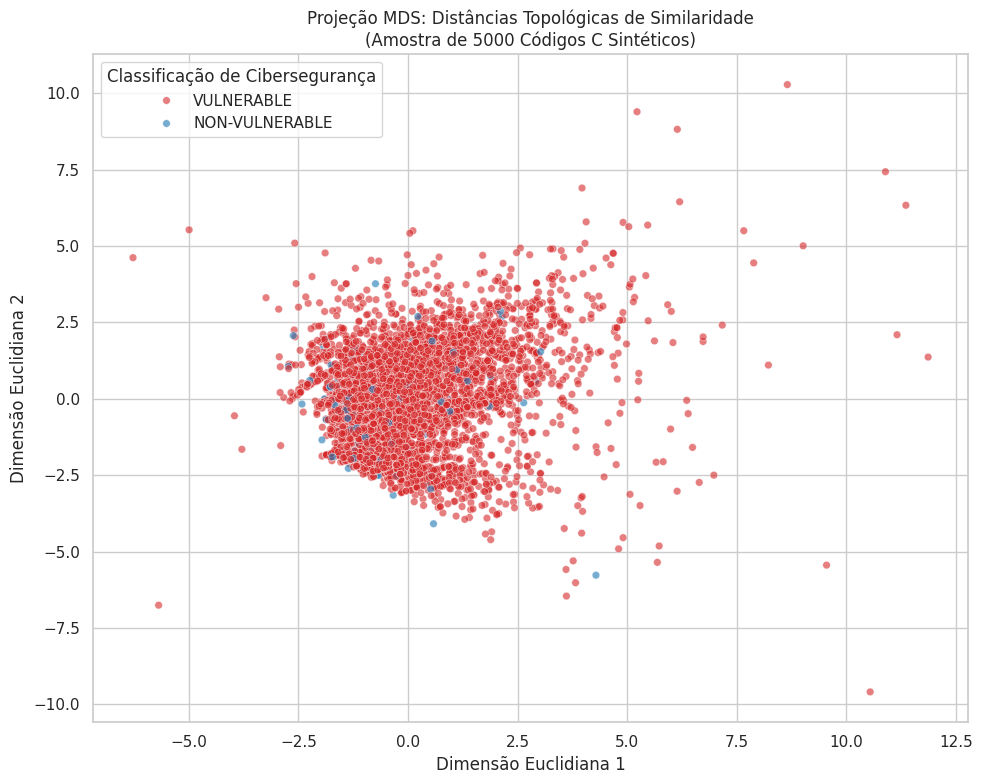

Processo finalizado! Arquivos salvos em:
- Dados: /home/deus/Documents/UEA/7_periodo/data_sci/pca_mds/ai-and-sec-issues_data-lake/src/03_gold/MDS/mds_results.parquet
- Imagem: /home/deus/Documents/UEA/7_periodo/data_sci/pca_mds/ai-and-sec-issues_data-lake/src/03_gold/MDS/mds_plot.png


In [21]:
print("Gerando e exportando o gráfico do MDS em PNG...")
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Dim_1', 
    y='Dim_2', 
    hue='category', 
    palette={'VULNERABLE': '#d62728', 'NON-VULNERABLE': '#1f77b4'},
    data=df_mds, 
    alpha=0.6, 
    s=30
)
plt.title(f'Projeção MDS: Distâncias Topológicas de Similaridade\n(Amostra de {N_SAMPLES} Códigos C Sintéticos)')
plt.xlabel('Dimensão Euclidiana 1')
plt.ylabel('Dimensão Euclidiana 2')
plt.legend(title='Classificação de Cibersegurança')
plt.tight_layout()

# Salva a figura em alta resolução antes de fechar
plt.savefig(MDS_IMAGE_PATH, dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print(f"Processo finalizado! Arquivos salvos em:")
print(f"- Dados: {os.path.abspath(MDS_RESULTS_PATH)}")
print(f"- Imagem: {os.path.abspath(MDS_IMAGE_PATH)}")